In [1]:
import os 
from thunderboltz import ThunderBoltz # imports the main simulation object 
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import thunderboltz
print(thunderboltz.__file__)


/home/emol/miniconda3/lib/python3.12/site-packages/thunderboltz/__init__.py


                     csfile  r1  r2                    rtype       B  p1  p2  \
0                     N.dat   0   1    ElasticFixedParticle2   0.000   0   1   
1   N->N(2p2_1D_3s_2De).dat   0   1  InelasticFixedParticle2  12.373   0   1   
2   N->N(2p2_3P_3d_2De).dat   0   1  InelasticFixedParticle2  13.021   0   1   
3   N->N(2p2_3P_3d_2Fe).dat   0   1  InelasticFixedParticle2  12.983   0   1   
4   N->N(2p2_3P_3d_2Pe).dat   0   1  InelasticFixedParticle2  12.963   0   1   
5   N->N(2p2_3P_3d_4De).dat   0   1  InelasticFixedParticle2  13.005   0   1   
6   N->N(2p2_3P_3d_4Fe).dat   0   1  InelasticFixedParticle2  12.971   0   1   
7   N->N(2p2_3P_3d_4Pe).dat   0   1  InelasticFixedParticle2  12.986   0   1   
8   N->N(2p2_3P_3p_2Do).dat   0   1  InelasticFixedParticle2  12.027   0   1   
9   N->N(2p2_3P_3p_2Po).dat   0   1  InelasticFixedParticle2  12.145   0   1   
10  N->N(2p2_3P_3p_2So).dat   0   1  InelasticFixedParticle2  11.618   0   1   
11  N->N(2p2_3P_3p_4Do).dat   0   1  Ine

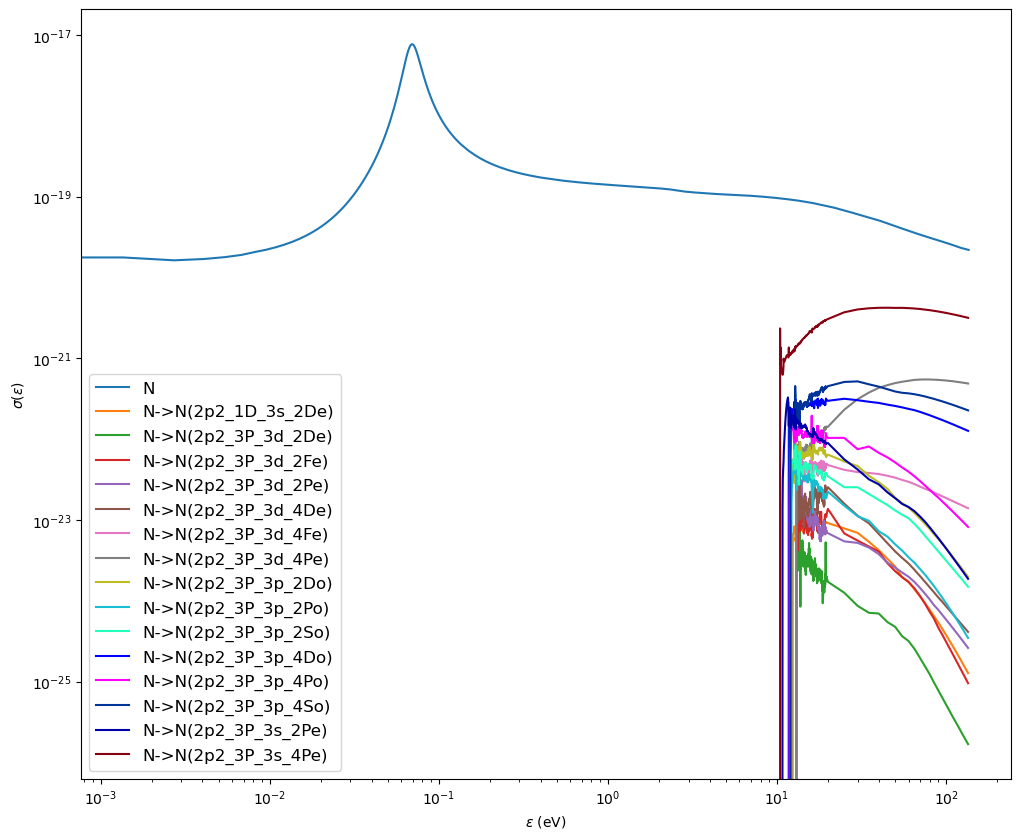

In [2]:
### Thunderboltz Run for Nitrogen ### 

xs = CrossSections() #initalize an empty cross sections object
xs.from_LXCat("cs_LXCat_all_N.txt") #ICS with excitation and ionization
xs.set_fixed_background(fixed=True)

mask = xs.table.rtype == "Ionization"
xs.table.loc[mask, "rtype"] = "IonizationNoEGen"

### viewing cross sections ###
print(xs.table)
print(xs.data) # view cs associated with each process 

xs.plot_cs() # plot of cs data 
plt.show()


In [3]:
# plot step by stepy data for any of the output parameters available in the time series table 
# default is mean energy, mobility and townshend ionization coefficient 
calc.plot_timeseries()

NameError: name 'calc' is not defined

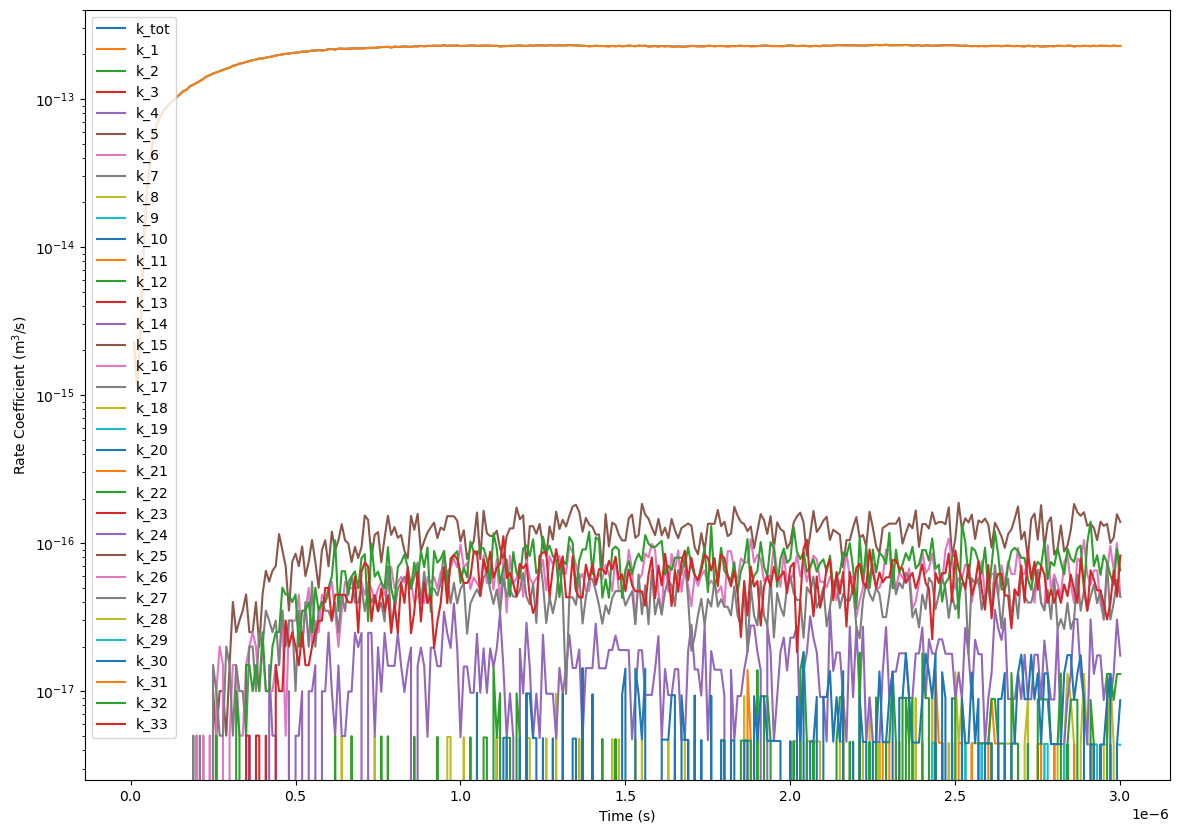

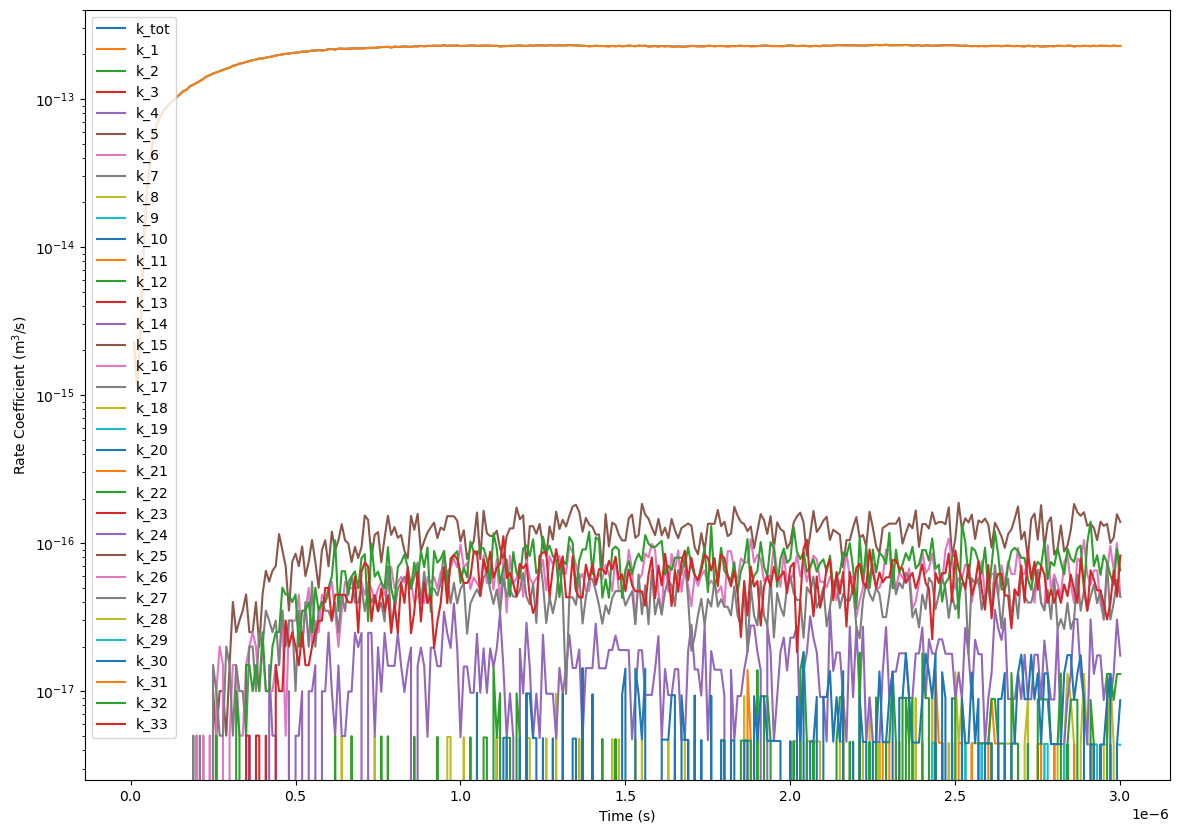

In [5]:
# plotting rate coefficients for every process 
calc.plot_rates()

                   csfile  r1  r2       rtype        B  p1  p2 model_name  \
0                  Ar.dat   0   1     Elastic   0.0000   0   1       None   
1   Ar->Ar(3d'[3/2]1).dat   0   1   Inelastic  14.3760   0   1       None   
2   Ar->Ar(3d'[3/2]2).dat   0   1   Inelastic  14.3430   0   1       None   
3   Ar->Ar(3d'[5/2]2).dat   0   1   Inelastic  14.3370   0   1       None   
4   Ar->Ar(3d'[5/2]3).dat   0   1   Inelastic  14.3480   0   1       None   
5    Ar->Ar(3d[1/2]0).dat   0   1   Inelastic  14.0690   0   1       None   
6    Ar->Ar(3d[1/2]1).dat   0   1   Inelastic  14.0810   0   1       None   
7    Ar->Ar(3d[3/2]1).dat   0   1   Inelastic  14.2270   0   1       None   
8    Ar->Ar(3d[3/2]2).dat   0   1   Inelastic  14.1000   0   1       None   
9    Ar->Ar(3d[5/2]2).dat   0   1   Inelastic  14.2010   0   1       None   
10   Ar->Ar(3d[5/2]3).dat   0   1   Inelastic  14.2120   0   1       None   
11   Ar->Ar(3d[7/2]3).dat   0   1   Inelastic  14.1650   0   1       None   

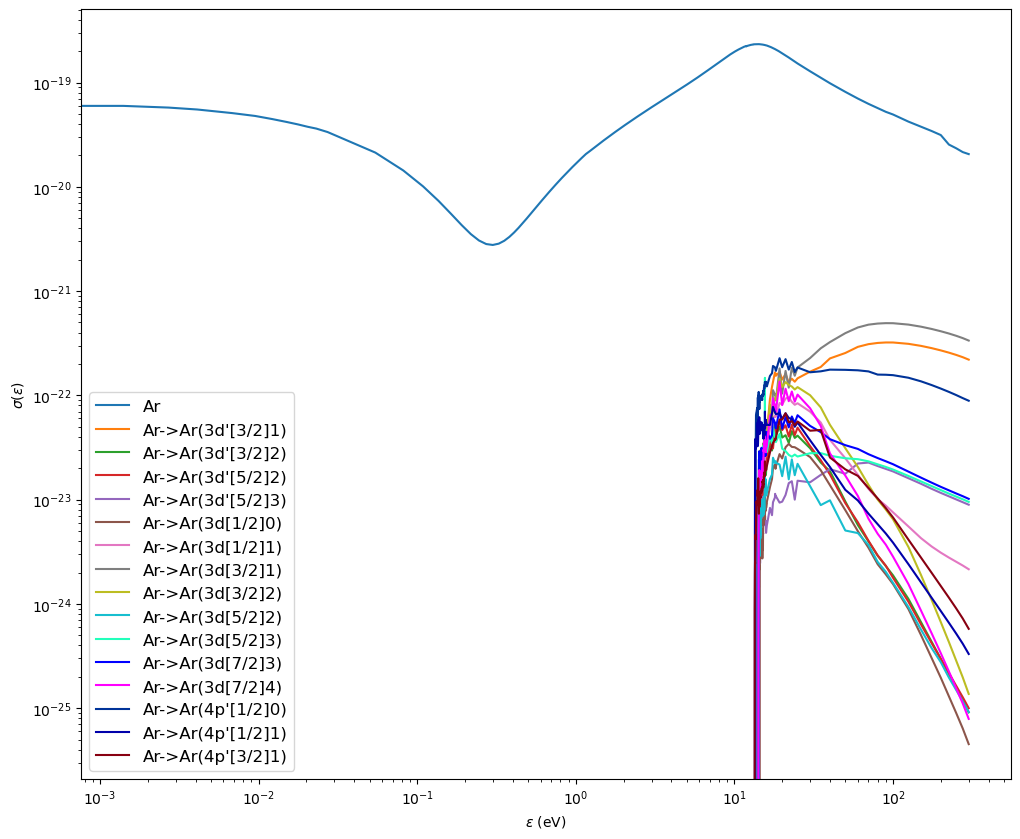

In [28]:
xs = CrossSections() #initalize an empty cross sections object
xs.from_LXCat("cs_LXCat_all.txt") #ICS with excitation and ionization

### viewing cross sections ###
print(xs.table)
print(xs.data) # view cs associated with each process 

xs.plot_cs() # plot of cs data 
plt.show()

In [6]:
import os 
from thunderboltz import ThunderBoltz
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import pandas as pd
import thunderboltz as tb

name = "1000Td"

calc = tb.read(f"Nitrogen_Aubin/{name}")

timeseries = calc.get_timeseries()
steady_state = calc.get_ss_params()

# save results
timeseries.to_csv(f"Nitrogen_Aubin/{name}/timeseries.csv", index=False)
steady_state.to_csv(f"Nitrogen_Aubin/{name}/steady.csv", index=False)

# extract transport parameters
transport_params = timeseries[["MEe", "mobN", "a_n"]].copy()

In [5]:
pd.read_csv("Nitrogen_Aubin/100Td/steady.csv").columns

FileNotFoundError: [Errno 2] No such file or directory: 'Argon-model-multi/100Td/steady.csv'

In [7]:
import glob
import pandas as pd
import thunderboltz as tb

steady_files = glob.glob(os.path.join("Nitrogen_Aubin", "*Td", "steady.csv"))

merged_data = []

for file_path in steady_files:
    ### Extract E/N value from folder name (e.g. "100Td" → 100) ###
    en_value = os.path.basename(os.path.dirname(file_path)).replace("Td", "")
    df = pd.read_csv(file_path)
    
    ### Handle case where steady.csv might have multiple rows (it usually has 1) ###
    row = df.iloc[0]

    merged_data.append({
        "E/N (Td)": float(en_value),
        "μN": row.get("mobN"),
        "D_XX": row.get("D_XX"),
        "D_YY": row.get("D_YY"),
        "D_ZZ": row.get("D_ZZ"),
        "Mean Energy (eV)": row.get("MEe"),
        "α/N ": row.get("a_n"),
        "μN_std": row.get("mobN_std"), 
        "Mean Energy std": row.get("MEe_std"), 
        "DLN std": row.get("D_ZZ_std"),
        "n_gas": row.get("n_gas"), 
        #"DTN std": row.get("MEe_std"), 
        
    })
    
### Combine all runs and sort by E/N ###
merged_df = pd.DataFrame(merged_data).sort_values("E/N (Td)").reset_index(drop=True)

### Save the combined file ### 
output_path = os.path.join("Nitrogen_Aubin", "Nitrogen_steady_all.csv")
merged_df.to_csv(output_path, index=False)
\
display(merged_df)

,E/N (Td),μN,D_XX,D_YY,D_ZZ,Mean Energy (eV),α/N,μN_std,Mean Energy std,DLN std,n_gas
0,1.0,9.581213e+24,7911.100763,19641.093822,751.700828,0.994519,0.000000e+00,7.052393e+24,0.018017,153605.755520,3.000000e+21
1,10.0,1.135578e+24,2188.388088,1778.391866,245.167660,1.151692,0.000000e+00,8.460172e+23,0.022517,15033.759158,3.000000e+21
2,100.0,1.418087e+24,336.048981,302.246216,225.611514,3.146464,7.060799e-23,1.072673e+23,0.044721,1140.236098,1.048300e+22
3,1000.0,4.974838e+23,129.647382,130.937067,125.222196,22.174952,2.781188e-20,1.455734e+22,0.136915,95.796959,5.320900e+22


                     csfile  r1  r2       rtype       B  p1  p2 model_name  \
0                     N.dat   0   1     Elastic   0.000   0   1       None   
1   N->N(2p2_1D_3s_2De).dat   0   1   Inelastic  12.373   0   1       None   
2   N->N(2p2_3P_3d_2De).dat   0   1   Inelastic  13.021   0   1       None   
3   N->N(2p2_3P_3d_2Fe).dat   0   1   Inelastic  12.983   0   1       None   
4   N->N(2p2_3P_3d_2Pe).dat   0   1   Inelastic  12.963   0   1       None   
5   N->N(2p2_3P_3d_4De).dat   0   1   Inelastic  13.005   0   1       None   
6   N->N(2p2_3P_3d_4Fe).dat   0   1   Inelastic  12.971   0   1       None   
7   N->N(2p2_3P_3d_4Pe).dat   0   1   Inelastic  12.986   0   1       None   
8   N->N(2p2_3P_3p_2Do).dat   0   1   Inelastic  12.027   0   1       None   
9   N->N(2p2_3P_3p_2Po).dat   0   1   Inelastic  12.145   0   1       None   
10  N->N(2p2_3P_3p_2So).dat   0   1   Inelastic  11.618   0   1       None   
11  N->N(2p2_3P_3p_4Do).dat   0   1   Inelastic  11.785   0   1 

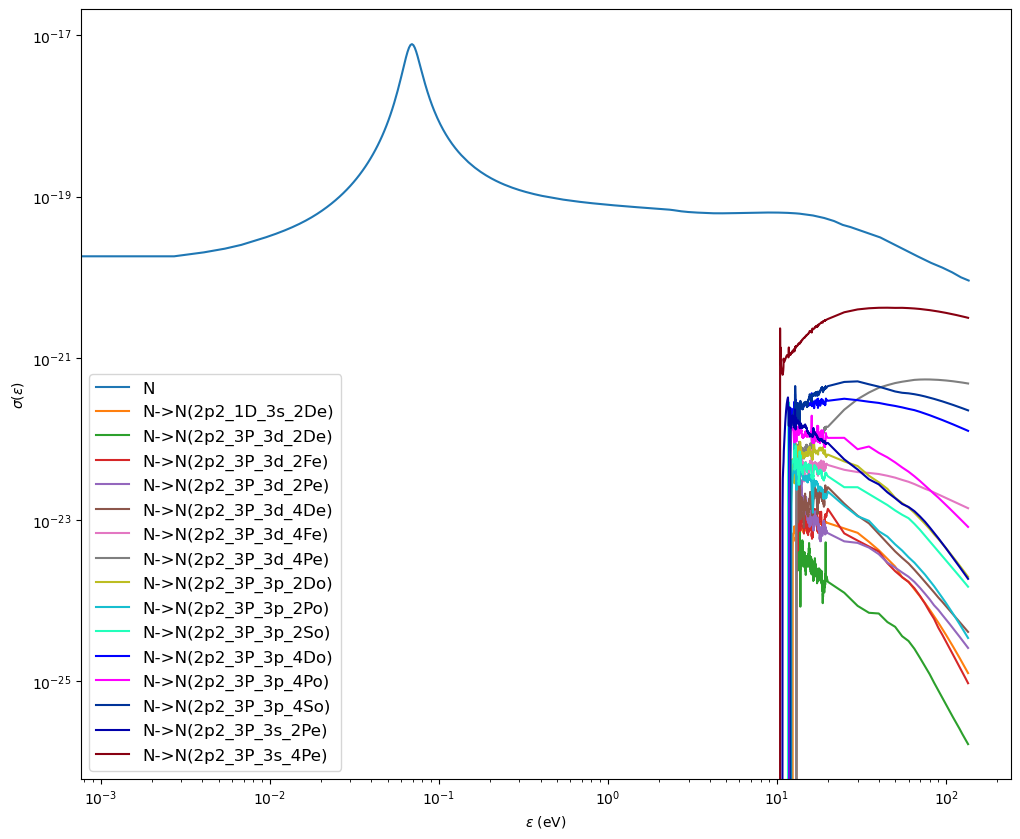

In [10]:
#momentum transfer 

import os 
from thunderboltz import ThunderBoltz # imports the main simulation object 
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import pandas as pd
import thunderboltz as tb

xs = CrossSections() #initalize an empty cross sections object
xs.from_LXCat("cs_LXCAT_all_mtcs_N.txt") #ICS with excitation and ionization

### viewing cross sections ###
print(xs.table)
print(xs.data) # view cs associated with each process 

xs.plot_cs() # plot of cs data 
plt.show()


['Dutton database', 'ETHZ (ETH Zurich, High Voltage Laboratory)', 'IST-Lisbon database', 'LAPLACE (measurements after 1975)', 'UNAM database']


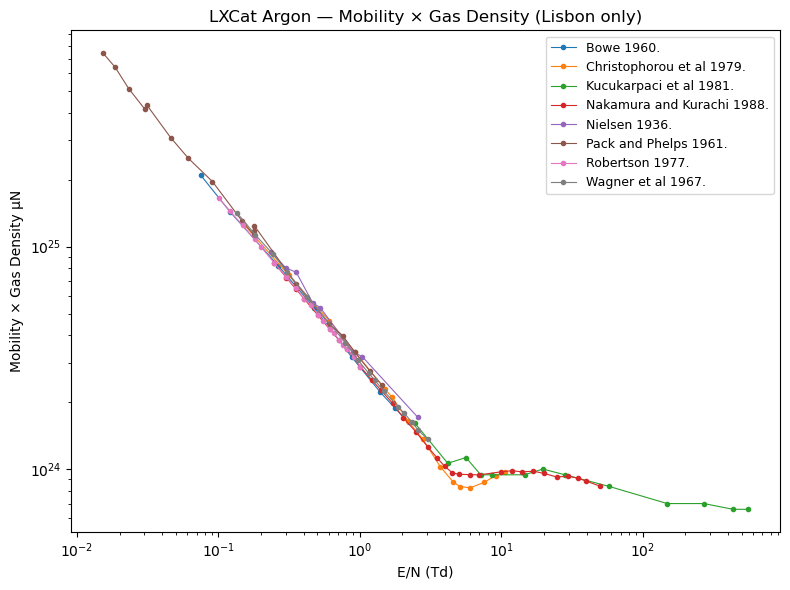

Lisbon min E/N (Td): 0.0153
Lisbon max E/N (Td): 551.29


In [15]:
### extract results on LXCat for comparison ### 
import pandas as pd
import matplotlib.pyplot as plt

def parse_lxcat_mobility(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    def is_dashes(s): return s.strip().startswith("-") and set(s.strip()) == {"-"}
    def as_float(s): return float(s.replace("D","E").replace(",", "."))

    current_db = None
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("DATABASE:"):
            current_db = line.split(":",1)[1].strip()
        elif line.startswith("SPECIES:") and ("e" in line and "/ Ar" in line):
            comment = ""
            j = i+1
            while j < len(lines) and not lines[j].startswith("COLUMNS:"):
                if lines[j].startswith("COMMENT:"):
                    comment = lines[j].split(":",1)[1].strip()
                j += 1
            j += 1
            if j < len(lines) and is_dashes(lines[j]):
                j += 1
                while j < len(lines) and not is_dashes(lines[j]):
                    s = lines[j].strip()
                    if s:
                        parts = s.split()
                        if len(parts) >= 2:
                            try:
                                en = as_float(parts[0])
                                muN = as_float(parts[1])
                                rows.append({
                                    "E/N (Td)": en,
                                    "μN": muN,
                                    "Database": current_db or "Unknown",
                                    "Reference": comment
                                })
                            except ValueError:
                                pass
                    j += 1
                i = j
                continue
        i += 1

    df = pd.DataFrame(rows)
    return df.sort_values(["Database","E/N (Td)"]).reset_index(drop=True)

# Parse uploaded file
path = "Mobility x gas density.txt"
lxcat_df = parse_lxcat_mobility(path)
lxcat_df = lxcat_df[lxcat_df["E/N (Td)"] >= 0.01].copy()

# Plot

# see what database strings look like
print(sorted(lxcat_df["Database"].dropna().unique().tolist()))

# keep only Lisbon entries (handles labels like "IST-Lisbon database")
lisbon = lxcat_df[lxcat_df["Database"].str.contains("lisbon", case=False, na=False)].copy()

# plot just Lisbon
plt.figure(figsize=(8,6))
for ref, g in lisbon.groupby("Reference"):
    g = g.sort_values("E/N (Td)")
    plt.loglog(g["E/N (Td)"], g["μN"], marker=".", lw=0.8, label=(ref or "IST-Lisbon"))

plt.xlabel("E/N (Td)")
plt.ylabel("Mobility × Gas Density μN")
plt.title("LXCat Argon — Mobility × Gas Density (Lisbon only)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Lisbon min E/N (Td):", lisbon["E/N (Td)"].min())
print("Lisbon max E/N (Td):", lisbon["E/N (Td)"].max())



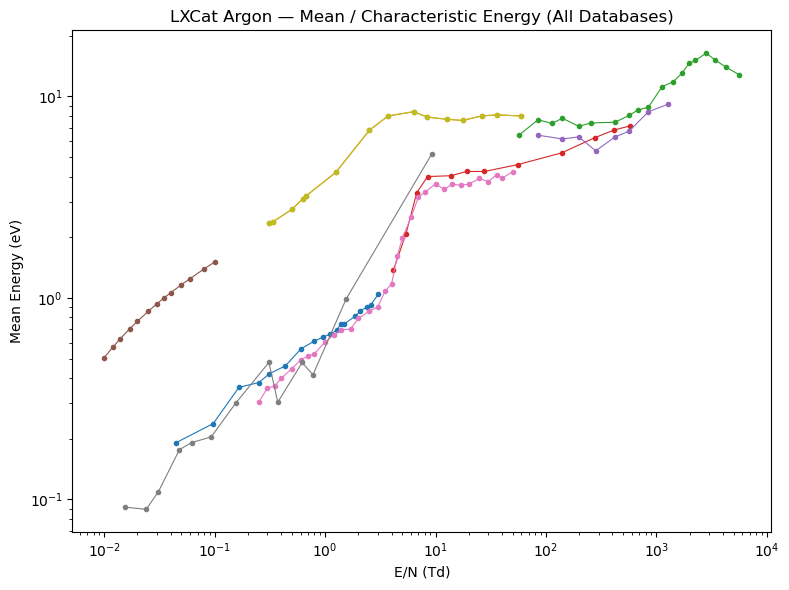

In [16]:
### extract mean energy from lxcat ### 

import pandas as pd
import matplotlib.pyplot as plt

# Path to your LXCat Energy.txt file
path = "Energy.txt"

def parse_lxcat_energy(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    def is_dashes(s):
        s = s.strip()
        return s and set(s) == {"-"}

    def as_float(s):
        return float(s.replace("D", "E").replace(",", "."))

    current_db = None
    i = 0
    n = len(lines)
    while i < n:
        line = lines[i]
        # Track DATABASE headers
        if line.startswith("DATABASE:"):
            current_db = line.split(":", 1)[1].strip()
            i += 1
            continue

        # Look for SPECIES e / Ar blocks
        if line.startswith("SPECIES:"):
            sl = line.lower().replace(" ", "")
            if ("species:e/ar" in sl) or ("species:e/argon" in sl):
                process, comment, params = "", "", ""
                j = i + 1
                while j < n and not lines[j].startswith("COLUMNS:"):
                    if lines[j].startswith("PROCESS:"):
                        process = lines[j].split(":", 1)[1].strip()
                    elif lines[j].startswith("PARAM.:"):
                        params = lines[j].split(":", 1)[1].strip()
                    elif lines[j].startswith("COMMENT:"):
                        comment = lines[j].split(":", 1)[1].strip()
                    j += 1
                if j >= n or not lines[j].startswith("COLUMNS:"):
                    i += 1
                    continue
                j += 1  # dashed line
                if j < n and is_dashes(lines[j]):
                    j += 1
                    while j < n and not is_dashes(lines[j]):
                        s = lines[j].strip()
                        if s:
                            parts = s.split()
                            if len(parts) >= 2:
                                try:
                                    en = as_float(parts[0])
                                    energy = as_float(parts[1])
                                    rows.append({
                                        "E/N (Td)": en,
                                        "Mean Energy (eV)": energy,
                                        "Database": current_db or "Unknown",
                                        "Process": process,
                                        "Reference": comment,
                                        "Params": params
                                    })
                                except ValueError:
                                    pass
                        j += 1
                    i = j
                    continue
        i += 1

    if not rows:
        return pd.DataFrame(columns=["E/N (Td)", "Mean Energy (eV)", "Database", "Process", "Reference", "Params"])
    df = pd.DataFrame(rows)
    # keep only characteristic/mean energy type data if multiple processes exist
    mask = df["Process"].str.contains("energy", case=False, na=False)
    df = df[mask].copy()
    return df.sort_values(["Database", "E/N (Td)"]).reset_index(drop=True)


# --- Parse and plot all databases ---
df_energy = parse_lxcat_energy(path)
df_energy = df_energy[df_energy["E/N (Td)"] >= 0.01].copy()

plt.figure(figsize=(8,6))
for (db, ref), g in df_energy.groupby(["Database", "Reference"]):
    g = g.sort_values("E/N (Td)")
    plt.loglog(g["E/N (Td)"], g["Mean Energy (eV)"],
               marker=".", lw=0.8, label=f"{db}: {ref}" if ref else db)

plt.xlabel("E/N (Td)")
plt.ylabel("Mean Energy (eV)")
plt.title("LXCat Argon — Mean / Characteristic Energy (All Databases)")
#plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


Databases found: ['Dutton database', 'ETHZ (ETH Zurich, High Voltage Laboratory)', 'LAPLACE (measurements after 1975)', 'UNAM database']


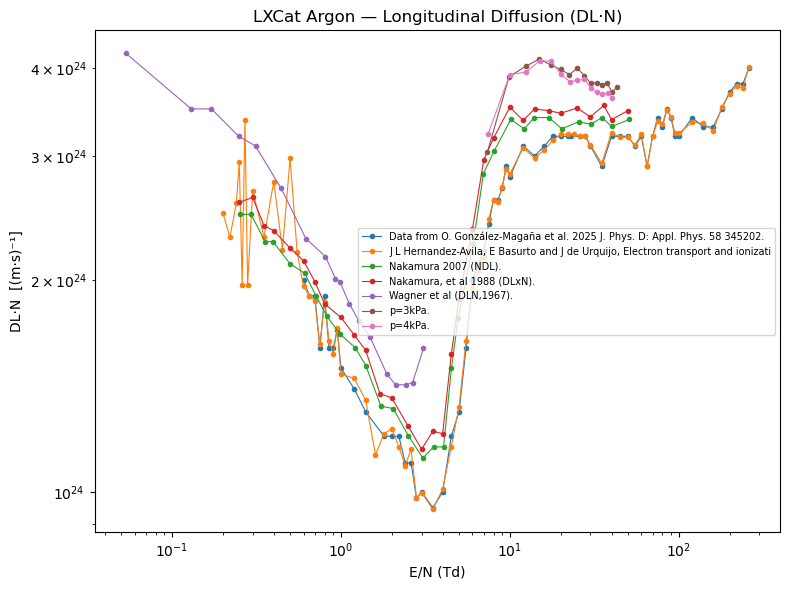

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_lxcat_diffusion(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    def is_dashes(s): 
        return s.strip().startswith("-") and set(s.strip()) == {"-"}
    def as_float(s): 
        return float(s.replace("D", "E").replace(",", "."))

    current_db = None
    current_comment = ""  # carry over top-level comment context
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("DATABASE:"):
            current_db = line.split(":", 1)[1].strip()
        elif line.startswith("COMMENT:"):
            # store but do NOT reset on every new line unless inside a block
            current_comment = line.split(":", 1)[1].strip()
        elif line.startswith("SPECIES:") and ("e" in line and "/ Ar" in line):
            # capture comment lines between SPECIES and COLUMNS
            block_comment = current_comment  # inherit previous top-level comment
            j = i + 1
            while j < len(lines) and not lines[j].startswith("COLUMNS:"):
                if lines[j].startswith("COMMENT:"):
                    block_comment = lines[j].split(":", 1)[1].strip()
                j += 1
            # now read numeric block
            j += 1
            if j < len(lines) and is_dashes(lines[j]):
                j += 1
                while j < len(lines) and not is_dashes(lines[j]):
                    s = lines[j].strip()
                    if s:
                        parts = s.split()
                        if len(parts) >= 2:
                            try:
                                en = as_float(parts[0])
                                dln = as_float(parts[1])
                                rows.append({
                                    "E/N (Td)": en,
                                    "DL_N": dln,
                                    "Database": current_db or "Unknown",
                                    "Reference": block_comment or current_db or "Unknown reference"
                                })
                            except ValueError:
                                pass
                    j += 1
                i = j
                continue
        i += 1

    df = pd.DataFrame(rows)
    return df.sort_values(["Database","E/N (Td)"]).reset_index(drop=True)

# Parse uploaded file
path = "Diffusion x gas density.txt"
lxcat_df = parse_lxcat_diffusion(path)

# Show databases present
print("Databases found:", sorted(lxcat_df["Database"].unique()))

# Plot grouped by reference (publication or comment)
plt.figure(figsize=(8,6))
for ref, g in lxcat_df.groupby("Reference"):
    g = g.sort_values("E/N (Td)")
    plt.loglog(g["E/N (Td)"], g["DL_N"], marker=".", lw=0.8, label=ref[:80])  # trim long refs
plt.xlabel("E/N (Td)")
plt.ylabel("DL·N  [(m·s)⁻¹]")
plt.title("LXCat Argon — Longitudinal Diffusion (DL·N)")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()


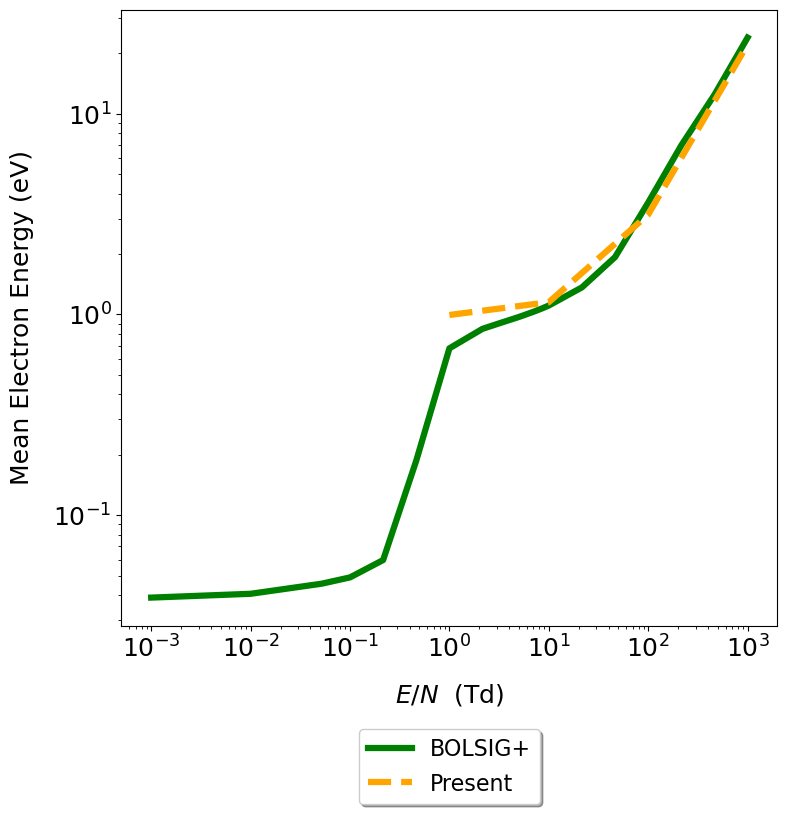

   E/N (Td)  Mean Energy (eV)_x  Mean Energy (eV)_y  Percent Error (%)
0       1.0            0.994519            0.678117          46.658869
1      10.0            1.151692            1.108071           3.936667
2     100.0            3.146464            3.611590          12.878696
3    1000.0           22.174952           23.979500           7.525376


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("Nitrogen_Aubin/Nitrogen_steady_all.csv")

bolsig = pd.read_fwf(
    "bolsig_meanenergy_N.txt",
    names=["E/N (Td)", "Mean Energy (eV)"],
    comment="#"
)

plt.figure(figsize=(8,8))

plt.plot(
    bolsig["E/N (Td)"],
    bolsig["Mean Energy (eV)"],
    lw=4.5,
    linestyle="-",
    color="green",
    label="BOLSIG+"
)

plt.plot(
    df1["E/N (Td)"],
    df1["Mean Energy (eV)"],
    lw=4.5,
    linestyle="--",
    color="orange",
    label="Present"
)

# Log scales
plt.xscale("log")
plt.yscale("log")

# Axis formatting
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("$E/N$  (Td)", fontsize=18, labelpad=14)
plt.ylabel("Mean Electron Energy (eV)", fontsize=18, labelpad=14)

plt.legend(
    fontsize=16,
    framealpha=1.0,
    fancybox=True,
    shadow=True,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    frameon=True
)

plt.tight_layout(pad=0.4)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.18, top=0.95)

plt.savefig("Mean_energy_N.pdf", bbox_inches='tight')
plt.show()

merged = pd.merge(df1, bolsig, on="E/N (Td)", how="inner")

merged["Percent Error (%)"] = (
    100 * abs(merged["Mean Energy (eV)_x"] - merged["Mean Energy (eV)_y"])
    / merged["Mean Energy (eV)_y"]
)

print(merged[[
    "E/N (Td)",
    "Mean Energy (eV)_x",
    "Mean Energy (eV)_y",
    "Percent Error (%)"
]])


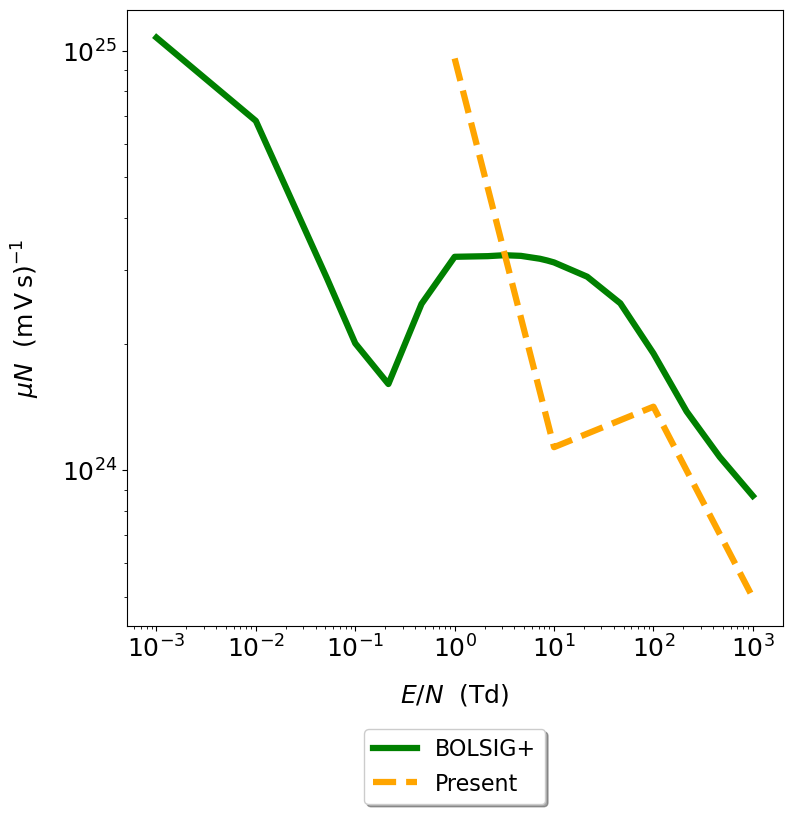


--- Present Model Percent Error (μN) ---
   E/N (Td)          μN_x          μN_y  Percent Error (%)
0       1.0  9.581213e+24  3.227240e+24         196.885674
1      10.0  1.135578e+24  3.129030e+24          63.708317
2     100.0  1.418087e+24  1.899650e+24          25.350065
3    1000.0  4.974838e+23  8.692430e+23          42.768161


In [12]:

import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("Nitrogen_Aubin/Nitrogen_steady_all.csv")

rows = []
with open("bolsig_mobN_N.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                en = float(parts[0].replace("D", "E"))
                mu = float(parts[1].replace("D", "E"))
                rows.append([en, mu])
            except ValueError:
                continue

bolsig = pd.DataFrame(rows, columns=["E/N (Td)", "μN"])

plt.figure(figsize=(8,8))

plt.plot(
    bolsig["E/N (Td)"],
    bolsig["μN"],
    lw=4.5,
    linestyle="-",
    color="green",
    label="BOLSIG+"
)

plt.plot(
    df1["E/N (Td)"],
    df1["μN"],
    lw=4.5,
    linestyle="--",
    color="orange",
    label="Present"
)

plt.xscale("log")
plt.yscale("log")

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("$E/N$  (Td)", fontsize=18, labelpad=14)
plt.ylabel(r'$\mu N$  $\mathrm{(m\,V\,s)^{-1}}$', fontsize=18, labelpad=14)

plt.legend(
    fontsize=16,
    framealpha=1.0,
    fancybox=True,
    shadow=True,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    frameon=True
)

plt.tight_layout(pad=0.4)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.18, top=0.95)

plt.savefig("mobility_plot_N.pdf", bbox_inches='tight')
plt.show()

merged1 = pd.merge(df1, bolsig, on="E/N (Td)", how="inner")

merged1["Percent Error (%)"] = (
    100 * abs(merged1["μN_x"] - merged1["μN_y"])
    / merged1["μN_y"]
)

print("\n--- Present Model Percent Error (μN) ---")
print(merged1[["E/N (Td)", "μN_x", "μN_y", "Percent Error (%)"]])




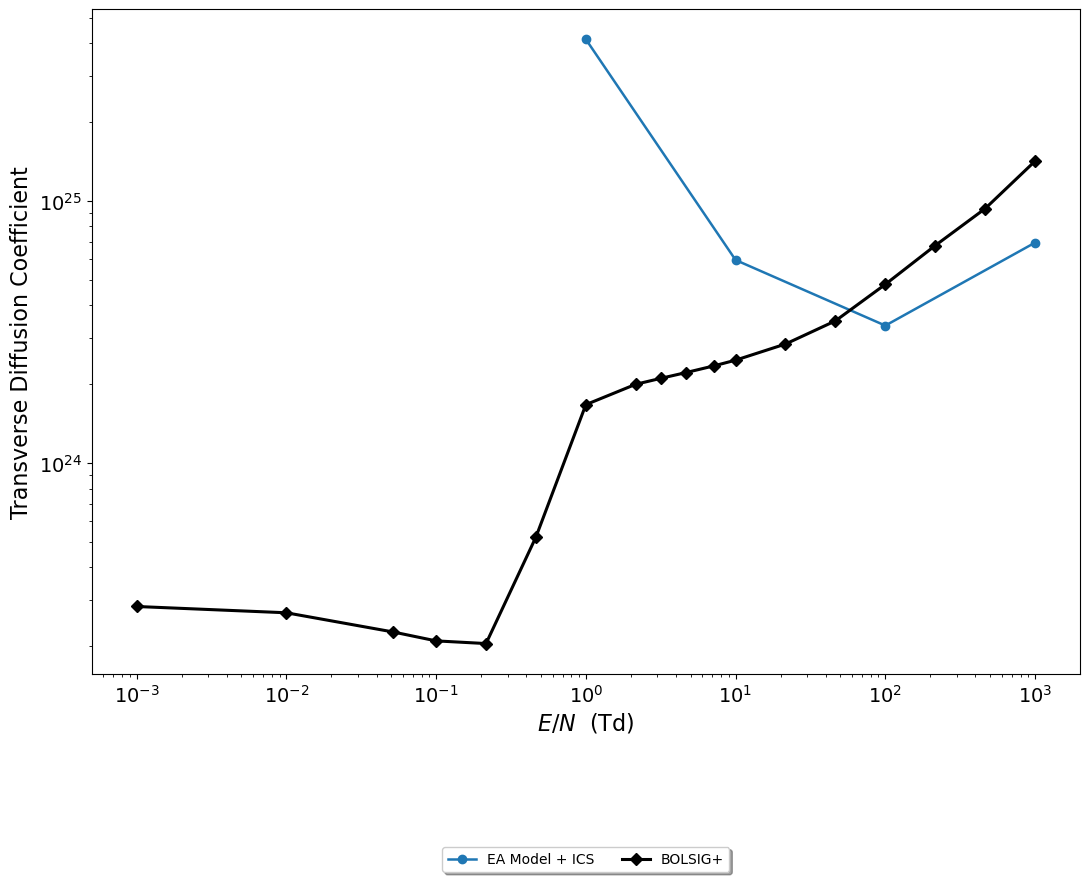

In [13]:
### Transverse Diffusion Coefficient ## 

rows = []
with open("bolsig_DTN_N.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                # force interpret as scientific notation with E
                en = float(parts[0].replace("D", "E"))
                a2 = float(parts[1].replace("D", "E"))
                rows.append([en, a2])
            except ValueError:
                continue

bolsig = pd.DataFrame(rows, columns=["E/N (Td)", "A6"])

plt.figure(figsize=(11,9))
plt.plot(df1["E/N (Td)"], 0.5 * df1["n_gas"] * (df1["D_XX"] + df1["D_YY"]), marker="o", lw=1.8, label="EA Model + ICS")
#plt.plot(df2["E/N (Td)"], 0.5 * df2["n_gas"] * (df2["D_XX"] + df2["D_YY"]), marker="o", lw=1.8, label="Model 2 - Isotropic + MTCS")
#plt.plot(df3["E/N (Td)"], 0.5 * df3["n_gas"] * (df3["D_XX"] + df3["D_YY"]), marker="o", lw=1.8, label="Model 1 - Isotropic + ICS")

plt.plot(bolsig["E/N (Td)"], bolsig["A6"],
         marker="D", lw=2.2, color="black", label="BOLSIG+")
    
plt.xscale("log")
plt.yscale("log")
plt.tick_params(axis='both', which='major', labelsize=14)
# Axis labels and title
plt.xlabel("$E/N$  (Td)", fontsize=16)
plt.ylabel("Transverse Diffusion Coefficient", fontsize=16)
#plt.title("Argon", fontsize=13)

# Grid and legend
plt.legend(
    fontsize=10,
    ncol=2,
    fancybox=True, 
    shadow=True,
    loc='upper center',           
    bbox_to_anchor=(0.5, -0.25),   
    frameon=True                  
)
plt.tight_layout()
plt.savefig("transverse_coefficient_N.pdf")
plt.show()



NameError: name 'handles' is not defined

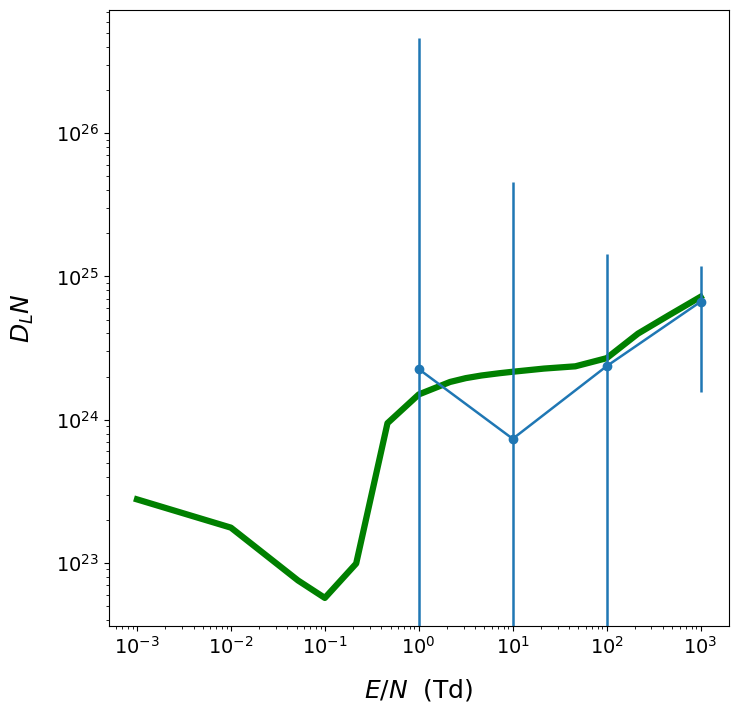

In [14]:
### Longtindual Diffusion Coefficient ### 

rows = []
with open("bolsig_DLN_N.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                # force interpret as scientific notation with E
                en = float(parts[0].replace("D", "E"))
                a2 = float(parts[1].replace("D", "E"))
                rows.append([en, a2])
            except ValueError:
                continue

bolsig = pd.DataFrame(rows, columns=["E/N (Td)", "DLN"])

plt.figure(figsize=(8,8))

plt.plot(bolsig["E/N (Td)"], bolsig["DLN"], lw=4.5, linestyle="-", color="green", label="BOLSIG+")

plt.errorbar(df1["E/N (Td)"],df1["n_gas"] * np.abs(df1["D_ZZ"]), yerr= df1["n_gas"] * np.abs(df1["DLN std"]), marker="o", lw=1.8, label="EA Model + ICS")
#plt.plot(df1["E/N (Td)"], df1["n_gas"] * np.abs(df1["D_ZZ"]), marker="o", lw=1.8, label="EA Model + ICS")
#plt.plot(df2["E/N (Td)"], df2["n_gas"] * df2["D_ZZ"], marker="o", lw=1.8, label="Model 2 - Isotropic + MTCS")
#plt.plot(df3["E/N (Td)"], df3["n_gas"] * np.abs(df3["D_ZZ"]), marker="o", lw=1.8, label="Model 1 - Isotropic + ICS")

plt.xscale("log")
plt.yscale("log")
plt.tick_params(axis='both', which='major', labelsize=14)
# Axis labels and title
plt.xlabel("$E/N$  (Td)", fontsize=18, labelpad=14)
plt.ylabel(r"$D_L N$", fontsize=18, labelpad=14)
#plt.title("Argon", fontsize=13)

# Grid and legend
plt.legend(handles, new_labels,
           fontsize=14,
           ncol=2,
           framealpha=1.0,
           fancybox=True,
           shadow=True,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           frameon=True)


plt.tight_layout(pad=0.4)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.18, top=0.95)
plt.savefig("longtindual_coefficient_N.pdf")
plt.show()